# selenium을 이용한 동적크롤링

### 웹페이지 크롤링 프로세스

1. 크롤링하려는 웹사이트 접속
2. 분석하려는 페이지를 찾고, 페이지 분석을 통해 어떤 태그와 속성이 사용되었는지 파악
3. 파이썬을 이용해 필요 데이터 추출
4. 추출한 데이터를 기반으로 분석 진행

## #1.selenium 소개

**동적 웹페이지 동작 단계**

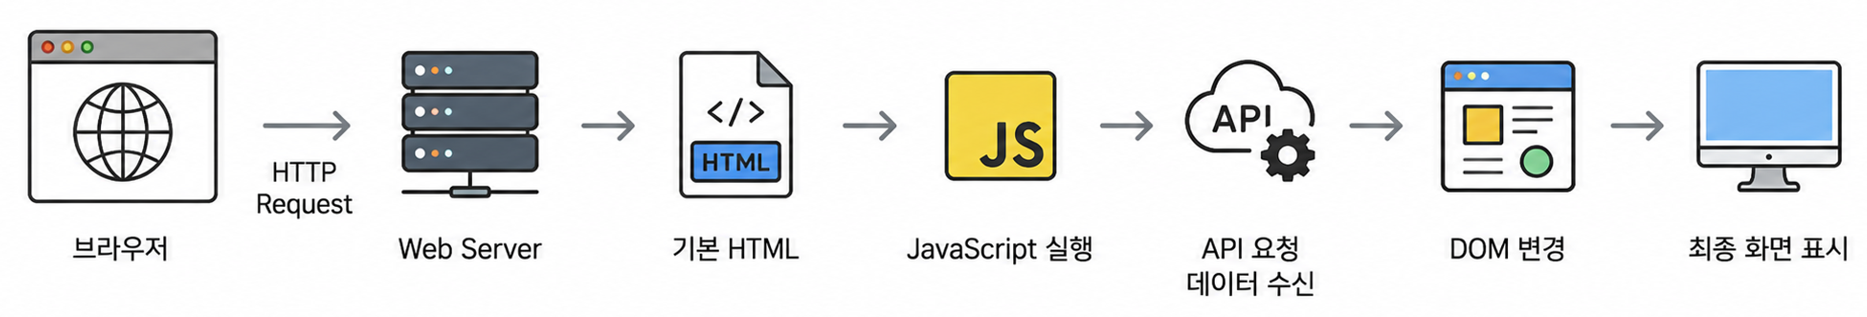

**Selenium이란?**
- https://www.selenium.dev/
- 주로 웹앱을 테스트하는데 이용하는 프레임워크
    - 웹 애플리케이션이 특정 브라우저에 잘 작동하는지 확인하기 위해 사용
- 웹브라우저 이용하는 자동화 프로그램
- 웹브라우저를 이용하여 할 수 있는 행동들을 코드로 작성하여 selenium이 이 코드를 웹브라우저에 전달하여 실행
- 웹 브라우저를 제어하는 함수(webdriver)를 포함한 패키지
- 서드파티 라이브러리

**Selenium 사용 목적**
- 사람이 직접 브라우저를 조작하는 것처럼 마우스 클릭, 키보드 입력, 스크롤 등의 웹 브라우저 동작을 코드로 자동 제어하기 위해 사용
- 주로 동적 웹 크롤링과 웹 서비스 테스트 자동화 목적으로 사용
- 동적 웹 크롤링 및 스크래핑
    - 자바스크립트(JavaScript)로 나중에 불러와지는 데이터 수집(브라우저가 HTML을 받은 후 JavaScript를 실행하여 데이터를 추가함)
    - 로그인, 버튼 클릭, 페이지 이동 등 상호작용이 필요한 정보 추출
- 웹 애플리케이션 테스트 자동화(QA)
    - 웹사이트 기능이 정상 작동하는지 반복 테스트 수행
    - 다양한 브라우저 환경에서 버그 사전 발견
- 반복 웹 작업 자동화
    - 정해진 시간에 웹서핑, 게시글 작성, 출석 체크 등 수동 작업 대체

**Selenium의 Webdriver**
- **webdriver**라는 API를 통해 운영체제에 설치된 Chrome등의 **브라우저를 제어**함
    - 브라우저를 직접 동작시킨다는 것은 JavaScript를 이용해 비동기적으로 혹은 뒤늦게 불러와지는 컨텐츠들을 가져올 수 있다는 것. 즉, '눈에 보이는' 컨텐츠라면 모두 가져올 수 있다는 뜻
    - requests모듈에서 요청은 브라우저에서 '소스보기'를 한 것과 같이 동작하여, JS등을 통해 동적으로 DOM이 변화한 이후의 HTML을 보여주지 않으나
    - Selenium은 실제 웹 브라우저가 동작하기 때문에 JS로 렌더링이 완료된 후의 DOM결과물에 접근이 가능함

## #2. selenium 설치

In [1]:
# !pip install selenium
# !pip show selenium

In [2]:
import selenium
selenium.__version__

'4.47.0'

## #3. Chrome 실행하기

- 최근 Selenium(버전 3.5 이후)에서는 Selenium Manager를 이용할 수 있으므로 별도로 ChromeDriver를 직접 다운로드하지 않아도 됨

In [3]:
from selenium import webdriver

driver = webdriver.Chrome()

In [4]:
# 브라우저별 드라이버 구동
driver = webdriver.Edge()
driver = webdriver.FireFox()

AttributeError: module 'selenium.webdriver' has no attribute 'FireFox'

- 웹페이지 열기

In [ ]:
driver.get('https://www.google.com')
print(driver.title)

- 브라우저 종료

In [ ]:
# driver.colse()
driver.quit()


---

> ### [참고] WebDriver Manager 설치
- 브라우저에 맞는 WebDriver를 자동으로 다운로드 받고 설치하기 위한 WebDriver Manager
- [WebDriver Manager for Python](https://github.com/SergeyPirogov/webdriver_manager)
```bash
!pip install webdriver-manager
# 제거
!pip uninstall webdriver-manager -y 
`
- 크롬(Chrome) 브라우저에 맞는 webdriver 설치
```python
# selenium 4.6 이상 부터는 webdriver 버전관리를 직접 selenium이 하므로 webdriver-manager 설치 필요 없음
from selenium.webdriver.chrome.service import Service as ChromeService
from webdriver_manager.chrome import ChromeDriverManager
service = ChromeService(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)
```

---

## #4. selenium 관련 함수

#### 브라우저 객체 생성 및 종료

- Webdriver 객체 생성
```driver = webdriver.Chrome(드라이버경로)```

- url에 접근하는 메서드
```get(url)```

- 브라우저 변화가 있을 때 
```driver.implicitly_wait(1)```

- 드라이버 종료
``` close()```
```quit()```

#### 현재 페이지 정보 확인
- 페이지 제목
``` driver.title```
- 현재 URL
```driver.current_url```
- HTML 가져오기
```html = driver.page_source```

#### 웹 요소 탐색
- `By`를 이용하여 요소 탐색
```from selenium.webdriver.common.by import By```

- `By` 모듈의 tag, css, xpath 찾는 기준    

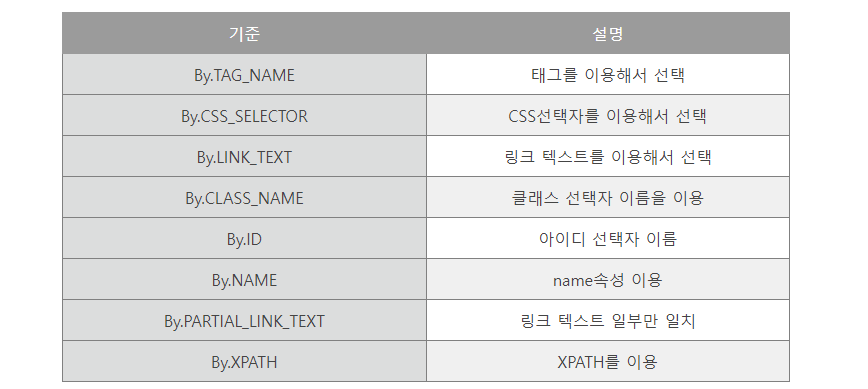

- 웹페이지 단일 element에 접근하는 메서드
    * find_element(By.TAG_NAME, 'tag_name')
    * find_element(By.ID, 'id_name')
    * find_element(By.CLASS_NAME, 'class_name')
    * find_element(By.CSS_SELECTOR, 'selector')
    * find_element(By.XPATH('xpath경로') : 스크립트 실행 경로를 찾아 접근

- 페이지의 여러 element에 접근하는 메서드
    * find_elements(By.TAG_NAME, 'tag_name')
    * find_elements(By.ID, 'id_name')
    * find_elements(By.CLASS_NAME, 'class_name')
    * find_elements(By.CSS_SELECTOR, 'selector')
    * find_elements(By.XPATH('xpath경로')    

- 자바스크립트 문장 실행
    * execute_script('자바스크립트')

    

- 접근한 페이지 source 추출
    * html=diver.page_source

- 찾은 element에 적용하는 행동 함수들
    * 마우스 click() 
    * 키보드 send_keys() 
 

- BeautifulSoup과 비교
| BeautifulSoup  | Selenium                 |
| -------------- | ------------------------ |
| `select_one()` | `find_element()`         |
| `select()`     | `find_elements()`        |
| `get_text()`   | `.text`                  |
| `get("href")`  | `.get_attribute("href")` |

## #5. Selenium 사용하기

### 브라우저에 맞는 웹드라이버 객체 생성

In [6]:
from selenium.webdriver.common.by import By

In [7]:
url = 'https://www.daum.net'
driver = webdriver.Chrome()
driver.get(url)

#웹페이지가 로드될 때 가지 기다림(시간 지정)

driver.implicitly_wait(3)
driver.get(url)

In [ ]:
url = 'https://www.daum.net'
driver = webdriver.Chrome()


In [ ]:
# 화면 캡처
driver.save_screenshot('crawl_data_main.png')

### 브라우저 종료

In [ ]:
driver.close()

### 웹 요소 찾기

- 웹 요소 하나 찾기

In [8]:
# fine_elements()
element = driver.find_element(By.TAG_NAME, 'a')
print(element)

<selenium.webdriver.remote.webelement.WebElement (session="df4582bbe4735da5638da0a060ecdcff", element="f.0900E829C54FE04E66E17BBE00BB6643.d.0E60FFB0E49B81361E635741DF24687E.e.91")>


- 여러 요소 찾기

In [11]:
# fine_elements()
elements = driver.find_elements(By.TAG_NAME, 'a')
print(element)

<selenium.webdriver.remote.webelement.WebElement (session="df4582bbe4735da5638da0a060ecdcff", element="f.0900E829C54FE04E66E17BBE00BB6643.d.0E60FFB0E49B81361E635741DF24687E.e.91")>


In [12]:
for link in elements[:20]:
    print(link.text)













지도
금융
메일
스포츠
날씨
사전
카페
전체 서비스


### CSS Selector 사용
: BeautifulSoup의 select() 메서드와 유사

- 태그 선택자

In [15]:
elements = driver.find_elements(By.CSS_SELECTOR, 'a')

- class 선택자

In [17]:
# Daum 메인페이지 상단에 있는 지도/금융/메일 등 링크
elements = driver.find_elements(By.CSS_SELECTOR, '.list_service')
elements

[<selenium.webdriver.remote.webelement.WebElement (session="df4582bbe4735da5638da0a060ecdcff", element="f.0900E829C54FE04E66E17BBE00BB6643.d.0E60FFB0E49B81361E635741DF24687E.e.131")>]

In [18]:
elements = driver.find_elements(By.CSS_SELECTOR, '.link_service')
len(elements)


24

In [20]:
[ e.text for e in elements ]
# for e in elements:
#     print(e.text)

['지도',
 '금융',
 '메일',
 '스포츠',
 '날씨',
 '사전',
 '카페',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '서비스 전체 보기']

- id 선택자

In [27]:
# 다음의 로그인 영역 Div : <div id="loginMy">
element = driver.find_element(By.CSS_SELECTOR, '#loginMy')
element.text

"카카오계정으로 로그인\n계정 찾기 회원가입\n실시간\n8\n손승원 음주운전 징역 2년\n신규\n실시간 트렌드 펼치기\n서교동 비\n27.8°C\n30˚C /\n24˚C\n미세 좋음\n초미세 보통\n쇼핑\n맨즈\n이전\n다음\n쿠팡\nG마켓\n옥션\n11번가\n올리브영\nSSG닷컴\n하프클럽\n이마트몰\nGS SHOP\n패션플러스\n트렌드패션\n클리어런스 특가 도로시 랩다이아\n24k 순금팔찌 썸머 거북이팔찌\n여름맞이 ~63% 스위스 덱카닉\n1주일점심걱정NO 직장인식비절약\n툭~ 걸치기 좋아 예쁜 신상 입고~\nWpc.양우산 SALE 여름기간 한정!\n해외여행 필수품 이거 챙기셨죠?\n다가오는~가을~ 2만원대로! 준비\n거울 속 팔뚝살 숨기고 싶어?\n매일 새롭게~ 예쁜 신상 입고\n라인은 예쁘게! 지금부터 입자~\n가을옷 지금쟁여 인기신상 할인\n1 /\n12\n이전페이지 보기\n다음페이지 보기\n광고\n금융\n증권 펼치기\n코스피\n6,907.02\n+0.79%\n코스닥\n801.96\n-4.63%\n코스피200\n1,094.81\n+1.28%\n실시간 트렌드\n오늘 15:03 기준\n실시간 트렌드 도움말보기\n1\n그래 이혼하자\n,상승\n2\n김옥숙 자택 압수수색\n,하락\n3\n교육교부금 개편\n,하락\n4\n민주당 전용기 최고위원\n,신규\n5\n노웅래 2심 무죄\n,상승\n6\n중국 태풍 마이삭\n,신규\n7\n르노코리아 임단협\n,하락\n8\n손승원 음주운전 징역 2년\n,신규\n9\n오세훈 항소심 재판\n,신규\n10\n기도산업\n,하락\n오늘의 루프\n연합뉴스\n망망대해서 5일간 '둥둥'…식수·식량도 없이 버텼는데 #shorts\n1 /\n10\n이전페이지 보기\n다음페이지 보기\n엔터테인먼트 랭킹\n카카오엔터테인먼트 제공\n도움말보기\n멜론 TOP100\n박스오피스\n인기 OTT\n1\nBiiiG\nBIGBANG (빅뱅)\n2\nLOVE ATTACK\nRESCENE (리센느)\n3\n아이오아이 (I.O.I)\n이전페이지 보기\n다음페이지

- 하위 요소

In [29]:
elements = driver.find_elements(By.CSS_SELECTOR, '.cont_login a')
[ e.text for e in elements]

['카카오계정으로 로그인', '계정 찾기', '회원가입']

- 속성

In [32]:
links = driver.find_elements(By.CSS_SELECTOR, 'a[href]')
for n, link in enumerate(links[:20]):
    text = link.text
    url = link.get_attribute('href')
    print(f'{n+1} {text}:{url}')

1 :https://www.daum.net/?t__nil_top=refresh#mainServiceTitle
2 :https://www.daum.net/?t__nil_top=refresh#gnbTitle
3 :https://www.daum.net/?t__nil_top=refresh#pagSetting
4 :https://www.daum.net/?t__nil_top=refresh#loginMy
5 :https://www.daum.net/?t__nil_top=refresh#newsTitle
6 :https://www.daum.net/?t__nil_top=refresh#enterTitle
7 :https://www.daum.net/?t__nil_top=refresh#sportsTitle
8 :https://www.daum.net/?t__nil_top=refresh#cafeTitle
9 :https://www.daum.net/?t__nil_top=refresh#interestTitle
10 :https://www.daum.net/?t__nil_top=refresh#shoppingTitle
11 :https://focus.daum.net/daum/pc/accessibility.html
12 :https://www.daum.net/
13 지도:https://map.kakao.com/?referrer=daumtop
14 금융:https://finance.daum.net/
15 메일:https://mail.daum.net/
16 스포츠:https://sports.daum.net/
17 날씨:https://weather.daum.net/
18 사전:https://dic.daum.net/
19 카페:https://top.cafe.daum.net/
20 전체 서비스:https://www.daum.net/?t__nil_top=refresh#none


In [34]:
#driver.close()

### 링크 주소 추출

### Chrome에서 Google 검색하기
: 사용자 브라우저 동작을 자동화할 수 있음

- Chrome 실행

In [36]:
from selenium import webdriver
from selenium.webdriver.common.by import By

driver = webdriver.Chrome()
driver.get('https://www.google.com')

- Google 검색창의 name 속성은 일반적으로 q

In [37]:
search = driver.find_element(By.NAME, 'q')

- 검색어 입력

In [38]:
search.send_keys('파이썬 웹 크롤링')

### 키보드 키 입력

In [40]:
from selenium.webdriver.common.keys import Keys

- Enter키 입력

In [43]:
search.send_keys(Keys.ENTER)

### 검색어 변경

- 기존 검색창 내용 삭제

In [45]:
search.clear()

- 새로운 검색어 입력

In [46]:
search.send_keys('BeautifulSoup Selenium')
search.send_keys(Keys.ENTER)

### 검색 결과 제목 수집

- 검색이 완료된 후 검색 결과의 제목 요소 추출

In [49]:
spans = driver.find_elements(By.CSS_SELECTOR,'span>a')
# XPATH //*[@id="rso"]/div[1]/div/div/div/div[1]/div/div/span

print(len(spans))

14


In [52]:
for sp in spans:
    print(f'{sp.text}\n\n')

[Python] BeautifulSoup와 Selenium의 차이는? - 개발자는 멋있다
티스토리
https://priming.tistory.com › ...


BeautifulSoup vs. Selenium - 사용법과 차이점
티스토리
https://today-knowlodge.tistory.com › ...


Selenium과 BeautifulSoup를 함께 사용하기
velog
https://velog.io › Selenium-BeautifulSoup


[BeautifulSoup/Selenium] BeautifulSoup, Selenium 기본 정리
티스토리
https://minding-deep-learning.tistory.com › ...


Beautiful Soup vs Selenium: Detailed Comparison in 2026
Thunderbit
https://thunderbit.com › blog › beautifulsoup-vs-selenium


Why would you want to use BeautifulSoup instead of ...
Reddit · r/Python
댓글 160개 이상 · 5년 전


[Python] 크롤링 방법과 비교 (requests, BeautifulSoup, selenium)
티스토리
https://deep-flame.tistory.com › ...


Selenium With BeautifulSoup Tutorial[Python] - Medium
Medium · Aamir Ahmad Ansari
4년 전


How can I parse a website using Selenium and ...
Stack Overflow
답변 3개 · 13년 전


[SIG 프로젝트] 2. Selenium과 BS4를 사용해보자(데이터 수집)
velog
https://velog.io › SIG-프로젝트-2.-Selenium과-BS4를-...


도움말


의견 보내기


개인정보처리방침


약관




### 개발자 도구에서 Selector 찾기
```
F12
 ↓
Elements
 ↓
수집하려는 요소 선택
 ↓
HTML 구조 확인
 ↓
id / class / 속성 확인
 ↓
CSS Selector 작성
```

```html
<div class="product">
    <a class="title" href="/product/100">
        노트북
    </a>
</div>
```
```python
driver.find_elements(
    By.CSS_SELECTOR,
    ".product .title"
)
```

### 대기

- time.sleep()으로 대기

```python
button.click()
time.sleep(2)
elements = driver.find_elements(...)

- WebDriverWait를 이용한 대기

In [54]:
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

In [ ]:
# 검색 결과의 h3가 나타날 때까지 기다림
wait = WebDriverWait(driver, 10)
wait.until(
    EC.presence_of_element_located((By.CSS_SELECTOR, 'h3'))
)

# 기다린 이후 작업
links = driver.find_elements(By.CSS_SELECTOR, 'h3')
for link in links:
    print(link.text)

In [57]:
# 앞의 검색 과정 자동화 완성
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

driver = webdriver.Chrome()
driver.get('https://www.google.com')

search = driver.find_element(By.NAME, 'q')
# 겁색어 입력 후 Enter 클릭
search.send_keys('파이썬 selenium 크롤링')
search.send_keys(Keys.ENTER)

# 검색 결과의 h3가 나타날 때까지 기다림
wait = WebDriverWait(driver, 20)
wait.until(
    EC.presence_of_element_located((By.CSS_SELECTOR, 'h3'))
)

# 기다린 이후 작업
links = driver.find_elements(By.CSS_SELECTOR, 'h3')
for link in links:
    print(link.text)

웹 크롤링 | 파이썬으로 동적 페이지 간단하게 크롤링 하기 ...
6) 동적 웹크롤링 - selenium 소개 및 기초사용법
Python과 Selenium을 활용한 웹 크롤링 실습 - 1 1 - 조연 블로그
초보자를 위한 웹 크롤링: Selenium과 Scrapy로 시작하기
자동화툴 'selenium'을 이용한 크롤러 구현 및 3사 데이터 ...
파이썬 셀레니움 맛보기 네이버 크롤링 - beautifulsoup ...
파이썬 셀레니움 고급편 (python selenium - 크롤링, 크롤러) ...
python(selenium) - 크롤링 기본 사용법 - pybi - 티스토리
[Python] Selenium을 활용한 동적 웹 크롤링


In [56]:

search = driver.find_element(By.NAME, 'q')
# 겁색어 입력 후 Enter 클릭
search.send_keys('파이썬 selenium 크롤링')
search.send_keys(Keys.ENTER)

# 검색 결과의 h3가 나타날 때까지 기다림
wait = WebDriverWait(driver, 10)
wait.until(
    EC.presence_of_element_located((By.CSS_SELECTOR, 'h3'))
)

# 기다린 이후 작업
links = driver.find_elements(By.CSS_SELECTOR, 'h3')
for link in links:
    print(link.text)

웹 크롤링 | 파이썬으로 동적 페이지 간단하게 크롤링 하기 ...
6) 동적 웹크롤링 - selenium 소개 및 기초사용법
Python과 Selenium을 활용한 웹 크롤링 실습 - 1 1 - 조연 블로그
초보자를 위한 웹 크롤링: Selenium과 Scrapy로 시작하기
자동화툴 'selenium'을 이용한 크롤러 구현 및 3사 데이터 ...
파이썬 셀레니움 맛보기 네이버 크롤링 - beautifulsoup ...
파이썬 셀레니움 고급편 (python selenium - 크롤링, 크롤러) ...
python(selenium) - 크롤링 기본 사용법 - pybi - 티스토리
[Python] Selenium을 활용한 동적 웹 크롤링


### 요소 클릭

In [61]:
driver = webdriver.Chrome()
driver.get('https://jolse.com/category/toners-mists/1019/')


In [66]:

# 첫번째 상품의 상세페이지로 이동
details = driver.find_elements(By.CLASS_NAME, '_evt_tracker0')
link_list = [ d.get_attribute('href') for d in details[1::2] ]

- 클릭 가능한 상태까지 기다린 후 클릭

In [69]:
details = driver.find_element(By.CLASS_NAME, '_evt_tracker0')
details.send_keys(Keys.ENTER)

wait = WebDriverWait(driver, 10)
wait.until(EC.presence_of_element_located(
            (By.CSS_SELECTOR, 'h2')
)
          )

titles = driver.find_elements(By.CSS_SELECTOR, 'h2')
[ t.text for t in titles ]

['',
 'B : Lab Essence Toner Pad 10ea/25g',
 'B : Lab Essence Toner Pad 10ea/25g']

In [72]:
btn = driver.find_element(By.CSS_SELECTOR, '.bynow_btn')
btn.click()

NoSuchElementException: Message: no such element: Unable to locate element: {"method":"css selector","selector":".bynow_btn"}
  (Session info: chrome=151.0.7922.174); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#nosuchelementexception
Stacktrace:
	chromedriver!GetHandleVerifier [0x7ff67297abb5+151b5]
	chromedriver!GetHandleVerifier [0x7ff67297ac10+15210]
	chromedriver!(No symbol) [0x7ff6724a5d6d]
	chromedriver!(No symbol) [0x7ff672501289]
	chromedriver!(No symbol) [0x7ff67250158c]
	chromedriver!(No symbol) [0x7ff672552027]
	chromedriver!(No symbol) [0x7ff67254ec0b]
	chromedriver!(No symbol) [0x7ff6724f37cc]
	chromedriver!(No symbol) [0x7ff6724f46f3]
	chromedriver!GetHandleVerifier [0x7ff672f9b79b+635d9b]
	chromedriver!GetHandleVerifier [0x7ff672f95ac6+6300c6]
	chromedriver!GetHandleVerifier [0x7ff672fbbcee+6562ee]
	chromedriver!GetHandleVerifier [0x7ff672998ffe+335fe]
	chromedriver!GetHandleVerifier [0x7ff6729a14

### 스크롤하기

** JavaScript를 이용해 브라우저를 스크롤 **
- execute_script() 메서드 이용해 자바스크립드 코드 실행

In [78]:
# 화면의 하단까지 이동
driver.execute_script(
    'window.scrollTo(0, document.body.scrollHeight); '
)

- 페이지 맨 위로 이동

In [77]:
# 화면의 상단까지 이동
driver.execute_script(
    'window.scrollTo(0, 0); '
)

- 특정 위치로 이동

In [87]:

driver.execute_script(
    'window.scrollTo(0, 400); '
)

- 일정한 간격으로 위 아래 이동

In [88]:
# 위로 이동
driver.execute_script(
    'window.scrollBy(0, -200); '
)

# 아래로 이동
driver.execute_script(
    'window.scrollBy(0, 200); '
)


- 200픽셀씩 3번 아래로 이동

In [90]:
import time

for i in range(3):
    driver.execute_script('window.scrollBy(0, 200); ')
    time.sleep(0.5)

- 일정한 간격씩 이동하여 페이지 맨 아래까지 이동

In [95]:
import time

scroll_size = 200

while True:
  # 현재 스크롤 위치
  current_position = driver.execute_script("return window.pageYOffset;")

  # 페이지 전체 높이
  page_height = driver.execute_script("return document.body.scrollHeight;")

  # 브라우저 화면 높이
  window_height = driver.execute_script("return window.innerHeight;")

  # 맨 아래에 도착했으면 종료
  if current_position + window_height >= page_height:
    break
  # 200px 아래로 이동
  driver.execute_script(f'window.scrollBy(0, {scroll_size});')
  time.sleep(0.3)

- 여러 번 반복 스크롤

- 페이지 높이를 이용한 무한 스크롤

In [96]:
import time

last_height = driver.execute_script("return document.body.scrollHeight")

while True:

  driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")

  time.sleep(2)

  new_height = driver.execute_script("return document.body.scrollHeight")

  if new_height == last_height:
    break

  last_height = new_height

### BeautifulSoup + Selenium 이용한 크롤링

```
Chrome
   ↑
Selenium
   │
   │ 페이지 접속
   │ JavaScript 실행
   │ 클릭
   │ 스크롤
   ↓
최종 DOM
   │
   │ driver.page_source
   ↓
BeautifulSoup
   │
   │ select()
   │ select_one()
   ↓
필요한 데이터 추출
```

#### 단계별 하위 요소 찾아가기
```python
product = driver.find_element(
    By.CSS_SELECTOR,
    ".product"
)
title_area = product.find_element(
    By.CSS_SELECTOR,
    ".title"
)
link = title_area.find_element(
    By.TAG_NAME,
    "a"
)
name = link.find_element(
    By.CSS_SELECTOR,
    ".name"
)
print(name.text)
```

In [97]:
driver.close()

-----